# Bessel–Gauss beam radial profile

This notebook explores two aspects of the axicon-based implementation of a Gauss-Bessel beam in Rao (2024):

1. How intensity $I_\ell^{BG}(r,z)$ changes along propagation z.
2. How radial rings given by $J_\ell^{2}(k_r, r)$ look at different z slices (fix a value for z).

Rao (Eq. 3.17) gives the axicon-generated Bessel beam intensity distribution as approximately proportional to:
$$
I_\ell^{BG}(r,z) \propto
\left(\frac{z}{z_{\max}^{G}}\right)^{2\ell+1}
\exp\left(-\frac{2z^2}{(z_{\max}^{G})^2}\right)
J_\ell^2(k_r r)
$$
with the range of the Bessel beam formed by a Gaussian beam source propagating through an axicon lens given by (Eq 3.18):
$$
z_{\max}^{G} = \frac{k w}{k_r}
\approx \frac{w}{(n-1)\alpha}
$$

* $w$ - Gaussian spot size of the axicon
* $n$ - axicon refractive index~=1.457 for UV fused silica at 650-698nm
* $\alpha$ - axicon base angle
* $k_r$ - magnitude of radial k-vector of BB, $k_r= k \sin(n-1)\alpha$

Rao notes increasing $w$ increases Bessel range, decreasing the axicon angle also increases Bessel range.

For 0th order:
$$
I_0^{BG}(r,z) \propto
\left(\frac{z}{z_{\max}^{G}}\right)
\exp\left(-\frac{2z^2}{(z_{\max}^{G})^2}\right)
J_0^2(k_r r)
$$
on-axis intensity peaks at:
$$
z_{\mathrm{peak}} = \frac{z_{\max}^{G}}{2}
$$

Code to render plots fors Gaussian beam width w=1500 microm initially generated with ChatGPT 5.5 (with significant edits), then refactored to sweep various beam widths. 

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

# ----------------------------
# Axicon / beam parameters
# ----------------------------

# wavelength_nm = 698      # clock interrogation wavelength, nm
wavelength_nm = 650     # alignment wavelength, nm

n_axicon = 1.457          # UV fused silica index near red
alpha_deg = 5.0          # axicon base angle, degrees

ell = 0                  # start with 0th-order Bessel beam

# Beam waists at the axicon
w_um_values = [250, 500, 1000, 1500, 2000]  # microm


# ----------------------------
# Unit conversions
# ----------------------------

wavelength_m = wavelength_nm * 1e-9
alpha_rad = np.deg2rad(alpha_deg)
k = 2 * np.pi / wavelength_m

# ----------------------------
# Small-angle approximation check
# ----------------------------


# Is small angle approximation reasonable?
# Exact Rao relation:
# k_r = k sin[(n - 1) alpha]
k_r = k * np.sin((n_axicon - 1) * alpha_rad)

# Small-angle approximation:
k_r_small_angle = k * (n_axicon - 1) * alpha_rad

print(f"k     = {k:.3e} 1/m")
print(f"k_r   = {k_r:.3e} 1/m")
print(f"k_r small-angle approx = {k_r_small_angle:.3e} 1/m")
print(f"relative error = {(k_r_small_angle - k_r) / k_r:.3e}")



k     = 9.666e+06 1/m
k_r   = 3.854e+05 1/m
k_r small-angle approx = 3.855e+05 1/m
relative error = 2.651e-04


In [97]:
# plot on-axis intensity profiles for different beam waists
def um_to_m(x_um):
    return x_um * 1e-6

def zmax_axicon(w_um, k=k, k_r=k_r):
    """
    Rao Eq. 3.18:
        zmax = k w / k_r
    """
    w_m = um_to_m(w_um)
    return k * w_m / k_r

def axicon_bessel_intensity(r_m, z_m, w_um, ell=0, k_r=k_r, normalize_peak=True):
    """
    Rao Eq. 3.17:
        I_l(r,z) ∝ (z/zmax)^(2l+1) exp[-2 z^2 / zmax^2] J_l^2(k_r r)
    """

    zmax = zmax_axicon(w_um)
    s = z_m / zmax

    axial_envelope = s**(2*ell + 1) * np.exp(-2 * s**2)
    radial_profile = jv(ell, k_r * r_m)**2

    I = axial_envelope * radial_profile

    if normalize_peak:
        s_peak = np.sqrt((2*ell + 1) / 4)
        envelope_peak = s_peak**(2*ell + 1) * np.exp(-2 * s_peak**2)
        I = I / envelope_peak

    return I

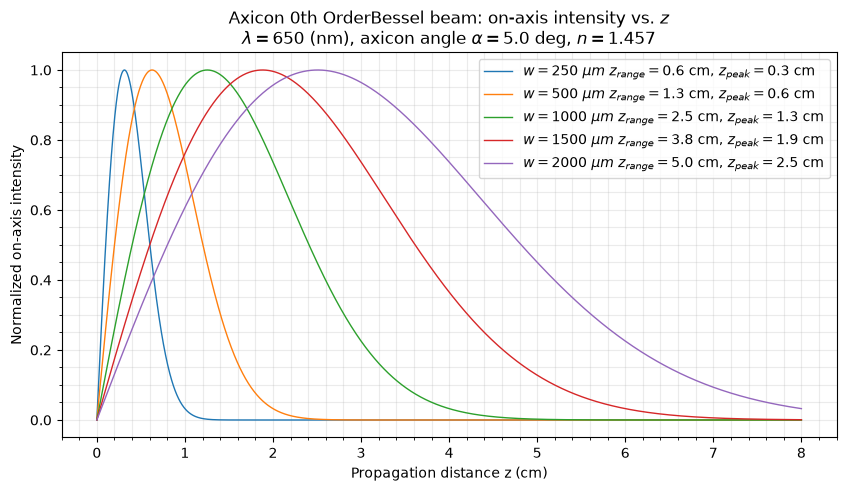

In [114]:
# plot on-axis intensity vs. z for different beam waists
z_m = np.linspace(0, 0.08, 2000)  # 0 to 30 cm

fig, ax = plt.subplots(figsize=(10, 5))
plt.minorticks_on()

for w_um in w_um_values:
    I_axis = axicon_bessel_intensity(
        r_m=0,
        z_m=z_m,
        w_um=w_um,
        ell=ell,
        normalize_peak=True,
    )

    zmax = zmax_axicon(w_um)
    zpeak = zmax / 2  # for ell = 0

    ax.plot(z_m * 100, I_axis, label=rf"$w={w_um}\ \mu m$ $z_{{range}}={zmax*100:.1f}$ cm, $z_{{peak}}={zpeak*100:.1f}$ cm", linewidth=1)



ax.set_xlabel("Propagation distance z (cm)")
ax.set_ylabel("Normalized on-axis intensity")
ax.set_title(r"Axicon 0th OrderBessel beam: on-axis intensity vs. $z$" 
             + "\n" + rf"$\lambda={wavelength_nm}$ (nm), axicon angle $\alpha={alpha_deg}$ deg, $n={n_axicon}$")
ax.grid(alpha=0.25, visible=True, which='both')

ax.legend()
plt.show()

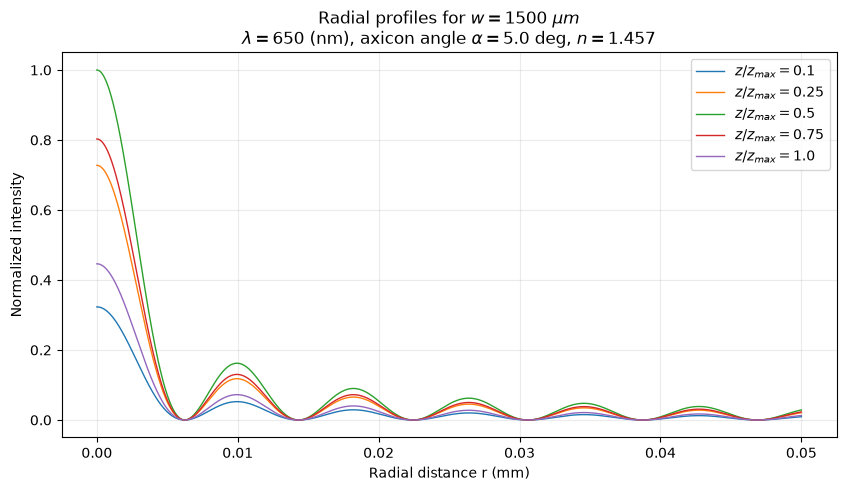

In [100]:
# plot radial intensity profiles at fixed values of z position
# at different z positions, the radial profile is the same BUT overall intensity is scaled by the axial envelope (z/zmax)
w_um = 1500

def make_normalized_r_vs_z_intensity_plot(w_um, ell=0):
    zmax = zmax_axicon(w_um)

    r_m = np.linspace(0, 0.05e-3, 2000)  # 0 to 0.5 mm
    z_fractions = [0.1, 0.25, 0.5, 0.75, 1.0]

    fig, ax = plt.subplots(figsize=(10, 5))

    for frac in z_fractions:
        z = frac * zmax
        I_r = axicon_bessel_intensity(
            r_m=r_m,
            z_m=z,
            w_um=w_um,
            ell=ell,
            normalize_peak=True,
        )

        ax.plot(r_m * 1e3, I_r, label=rf"$z/z_{{max}}={frac}$", linewidth=1)

    ax.set_xlabel("Radial distance r (mm)")
    ax.set_ylabel("Normalized intensity")
    ax.set_title(rf"Radial profiles for $w={w_um}\ \mu m$"
                 + "\n" + rf"$\lambda={wavelength_nm}$ (nm), axicon angle $\alpha={alpha_deg}$ deg, $n={n_axicon}$")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

make_normalized_r_vs_z_intensity_plot(w_um=1500)

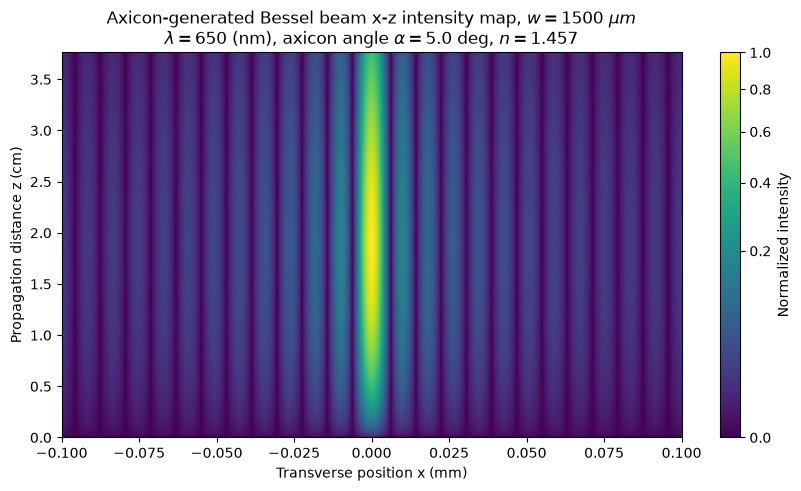

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv
from matplotlib.colors import PowerNorm

def make_xz_intensity_map(w_um, ell=0):
    zmax = zmax_axicon(w_um)

    # Use signed transverse coordinate x instead of one-sided radial coordinate r
    x_m = np.linspace(-0.1e-3, 0.1e-3, 900)  # -0.35 mm to +0.35 mm
    z_m = np.linspace(0, zmax, 900)

    X, Z = np.meshgrid(x_m, z_m)
    R = np.abs(X)

    I_map = axicon_bessel_intensity(
        r_m=R,
        z_m=Z,
        w_um=w_um,
        ell=ell,
        normalize_peak=True,
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    im = ax.imshow(
        I_map,
        extent=[x_m.min()*1e3, x_m.max()*1e3, z_m.min()*100, z_m.max()*100],
        origin="lower",
        aspect="auto",
        norm=PowerNorm(gamma=0.45, vmin=0, vmax=1),
    )

    ax.set_xlabel("Transverse position x (mm)")
    ax.set_ylabel("Propagation distance z (cm)")
    ax.set_title(rf"Axicon-generated Bessel beam x-z intensity map, $w={w_um}\ \mu m$" + 
                "\n" + rf"$\lambda={wavelength_nm}$ (nm), axicon angle $\alpha={alpha_deg}$ deg, $n={n_axicon}$")

    fig.colorbar(im, ax=ax, label="Normalized intensity")
    plt.show()

make_xz_intensity_map(w_um=1500)

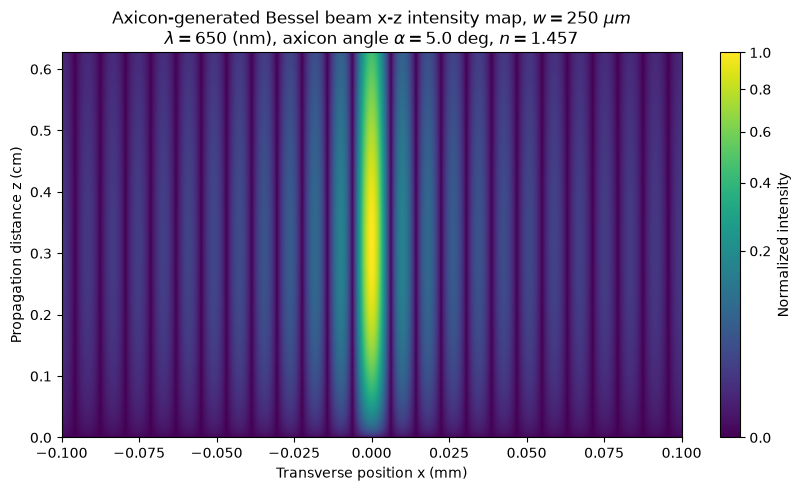

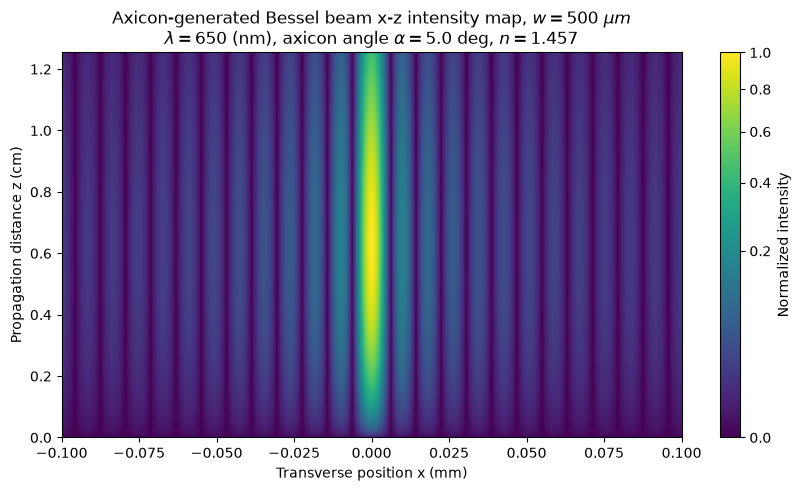

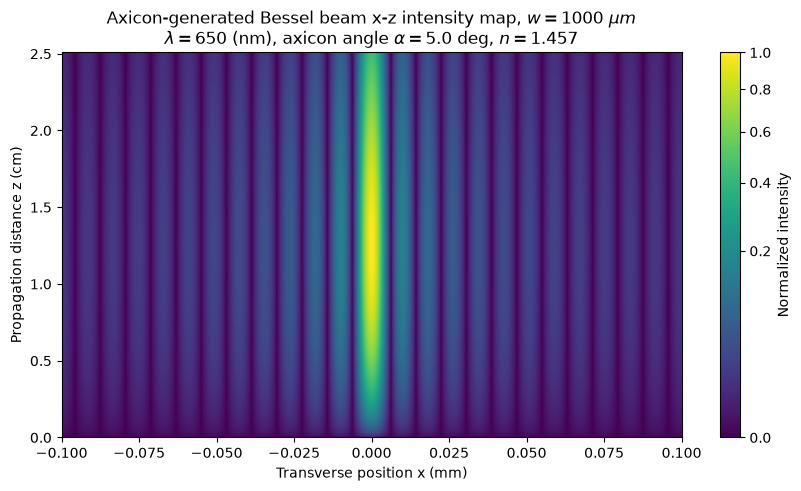

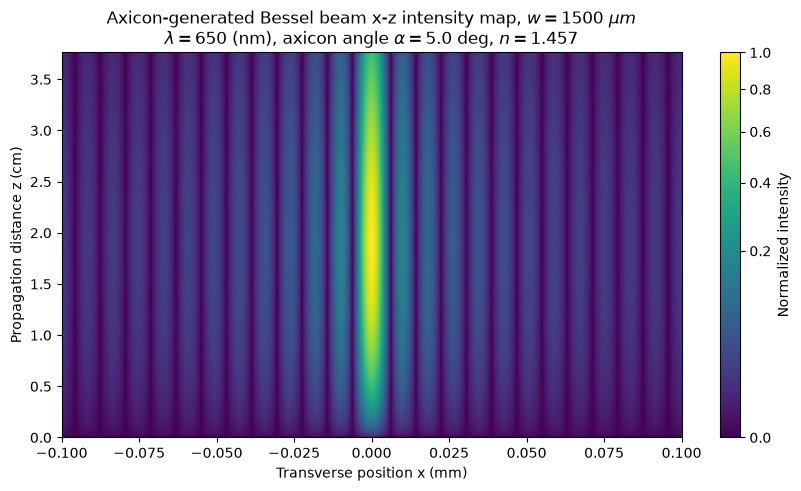

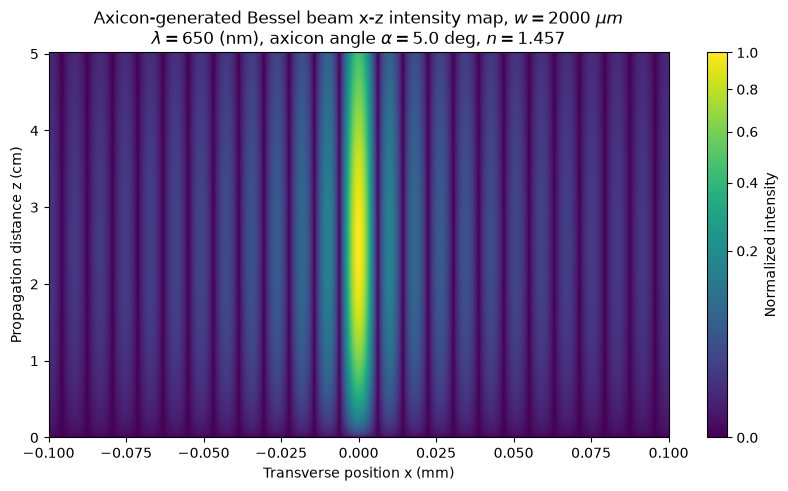

In [102]:
# sanity check: plotting the radial Bessel profile should not change for different beam waists, if we plot position normalized as z/zmax
# in othher words, the radial profile is the same at a given fraction of zmax, regardless of the beam waist
for w_um in w_um_values:
    make_xz_intensity_map(w_um=w_um)
    # make_normalized_r_vs_z_intensity_plot(w_um=w_um)